In [7]:
install.packages("dplyr")
install.packages('ggfortify')
# https://holab-hku.github.io/R-workshop/rna-seq-analysis-in-r.html#select-highly-variable-genes
BiocManager::install("apeglm",force=TRUE)
BiocManager::install("DEGreport",  force=TRUE)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'bbmle', 'bdsmatrix', 'BH', 'Biobase', 'BiocGenerics',
  'BiocParallel', 'Biostrings', 'boot', 'bslib', 'callr', 'circlize', 'cli',
  'cluster', 'coda', 'codetools', 'commonmark', 'cowplot', 'cpp11', 'curl',
  'data.table', 'DBI', 'dbplyr', 'DelayedArray', 'DESeq2', 'digest', 'e1071',
  'edgeR', 'fansi', 'foreign', 'future', 'future.apply', 'GenomeInfoDb',
  'GenomeInfoDbData', 'GenomicRanges', 'ggdendro', 'ggplot2', 'ggrepel', 'gh',
  'globals', 'glue', 'gplots', 'hardhat', 'haven', 'htmltools', 'htmlwidgets',
  'httpuv', 'IRanges', 'jsonlite', 'later', 'lattice', 'lava', 'limma',
  'listenv', 'locfit', 'maps', 'MASS', 'Matrix', 'MatrixGenerics',
  'matrixStats', 'mgcv', 'nlme', 'NMF', 'parallelly', 'pbdZMQ', 'pkgbuild',
  'processx', 'progress', 'ps', 'psych', 'quantmod', 'ragg', 'Rcpp',
  'RcppArmadillo', 'RcppEigen', 'RCurl', 'readr', 'recipes', 'remotes', 'repr',
  'reprex', 'rlang', 'rm

In [12]:
#PCA
library(stats)
library(ggfortify)
library(apeglm)
library(DEGreport)

In [13]:
filepath = "/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_rnaseq_sample_list.tsv"
sample_info <- read.table(filepath, header=TRUE, row.names=1)
head(sample_info)

,genotype,tissue,treatment,time_point,replicate
,<chr>,<chr>,<chr>,<int>,<chr>
A111,UCR,VS,control,1,r1
A211,UCR,VS,control,1,r2
A311,UCR,VS,control,1,r3
A411,UCR,VS,control,1,r4
A112,Epicselect,VS,control,1,r1
A212,Epicselect,VS,control,1,r2


In [10]:
# Load raw count data
filepath = "/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_quant_isr_counts.tsv"
raw_counts <- read.table(filepath, header = TRUE, row.names = 1)


In [11]:
View(raw_counts)

,A111,A211,A311,A411,A112,A212,A312,A412,A121,A221,⋯,C312,C412,C121,C221,C321,C421,C122,C222,C322,C422
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
VigunL059001.v1.2,0,0,0,3,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,0
VigunL000101.v1.2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
VigunL000300.v1.2,0,0,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,32,0,0,0,0
VigunL000202.v1.2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,2,0,0,2,0,0,0,0
VigunL001800.v1.2,1432,2186,1558,2328,873,2594,1102,943,2764,4117,⋯,426,367,1077,796,1249,743,616,1026,877,839
VigunL059106.v1.2,0,0,0,0,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0
VigunL059406.v1.2,817,220,781,301,367,1008,950,698,1320,960,⋯,576,414,1129,792,769,911,614,706,980,874
VigunL002300.v1.2,0,0,2,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
VigunL059007.v1.2,50,0,0,0,0,0,0,0,0,0,⋯,0,0,13,0,0,14,0,0,0,0


In [ ]:
group <- factor(paste(sample_info$genotype, 
                      sample_info$tissue, 
                      sample_info$treatment,
                      sample_info$time_point, sep="_"))
group

In [ ]:
scaling_factor <- apply(countdata, 2, sum)/1000000
myRPM <- mapply('/', countdata, scaling_factor)

In [214]:
table(rowSums(myRPM > 0.5))
summary(rowSums(myRPM > 0.5) >= 2)




    0     1     2     3     4     5     6     7     8     9    10    11    12 
 3505   692   401   265   230   185   178   158   154   120   109   105   126 
   13    14    15    16    17    18    19    20    21    22    23    24    25 
  137    97   104    94   123   128   132   107    95   114   122   141   129 
   26    27    28    29    30    31    32    33    34    35    36    37    38 
  134    86   124   121   120    99   104   114   108   116   115   134   104 
   39    40    41    42    43    44    45    46    47    48 
  136   137   157   175   205   267   316   433   818 14465 

   Mode   FALSE    TRUE 
logical    4197   22142 

In [215]:
myRPM.keep <- myRPM[rowSums(myRPM > 0.5) >= 2,]
dim(myRPM.keep)

[1] 22142    48

In [216]:
myRPM.keep 

A111,A211,A311,A411,A112,A212,A312,A412,A121,A221,⋯,C312,C412,C121,C221,C321,C421,C122,C222,C322,C422
0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.01106917,0.00000000,0.00000000,0.00000000,⋯,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.39755592,0.00000000,0.00000000,0.00000000,0.00000000
15.90105405,22.86394245,17.41868445,28.47631043,13.67856592,29.76925465,12.19822091,12.22184481,28.98882693,38.16896476,⋯,6.38823892,5.28690568,13.65562242,11.27344542,15.38228317,9.23075142,7.96746130,13.22016665,11.98880806,11.55083763
9.07203991,2.30103721,8.73170254,3.68185972,5.75032496,11.56800643,10.51570768,9.04649807,13.84415758,8.90022011,⋯,8.63761882,5.96397534,14.31494681,11.21679494,9.47075721,11.31791997,7.94159292,9.09691779,13.39684367,12.03269617
0.33312264,0.85765932,0.83851177,1.49231524,1.58251450,1.70995333,0.67521912,0.47954216,1.23758378,0.99200370,⋯,0.11996693,0.54741803,0.29162425,0.39655336,0.12315679,0.04969449,0.05173676,0.18039214,0.24606448,0.15144126
0.39974717,0.13597038,3.25342566,2.66659608,1.89588371,0.49347646,0.56452747,0.66099055,0.08390399,0.09271063,⋯,2.12941297,0.95077868,0.48181398,0.38239074,0.11084111,0.16150709,0.36215733,1.13389344,1.02526865,0.19274342
39.66380242,45.27813672,47.22498276,70.28560125,46.37864276,30.81358857,47.03288626,30.22411675,73.82501908,32.87518801,⋯,25.59794329,30.03596277,45.03692743,38.52232606,40.08753541,38.72443091,14.15000433,21.20896130,26.15118565,15.10282345
0.34422673,1.48521493,1.02857444,1.46785105,7.14481794,2.98381118,0.92980994,1.15349331,1.63612771,0.74168501,⋯,2.26437577,0.30252049,21.36464603,16.81102979,2.03208705,0.64602836,0.41389409,20.71932550,2.47431500,0.71590412
0.64403711,0.81582228,0.32422455,0.53821205,3.35305052,3.56909722,0.76377245,0.37585737,0.68171988,0.49136632,⋯,0.52485531,0.12965164,5.68033319,6.42982942,2.38924174,0.43482678,0.25868381,5.47618989,2.58367699,0.31664990
0.75507799,0.77398524,0.38012533,0.55044414,1.62951988,0.94104814,0.34314415,0.36289677,1.48929574,0.24104763,⋯,0.40488838,0.04321721,5.27459510,3.75309427,0.43104877,0.24847245,0.10347352,3.40168031,0.82021492,0.05506955
1.12151289,0.88903710,0.46956659,0.68499716,0.57973303,0.96400054,0.40955914,0.22033018,0.48244792,0.45428207,⋯,0.04498760,0.05762295,0.13947247,0.14162620,0.11084111,0.32301418,0.07760514,0.12885153,0.25973472,0.12390648


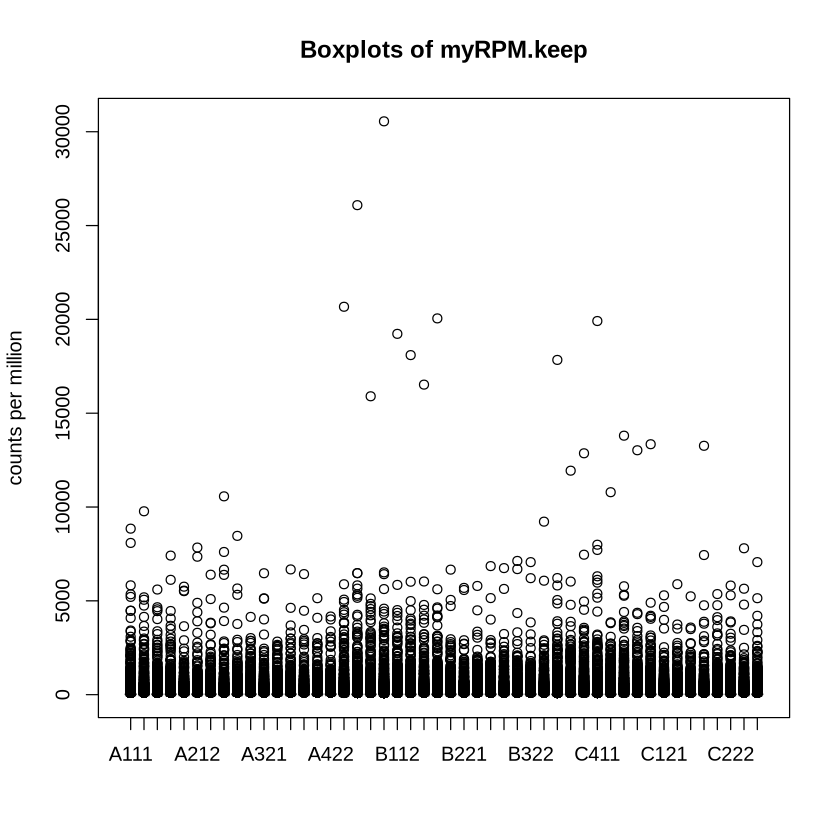

In [217]:
myRPM.keep <- as.matrix(myRPM.keep)
boxplot(myRPM.keep, xlab="", ylab="counts per million")
title("Boxplots of myRPM.keep")

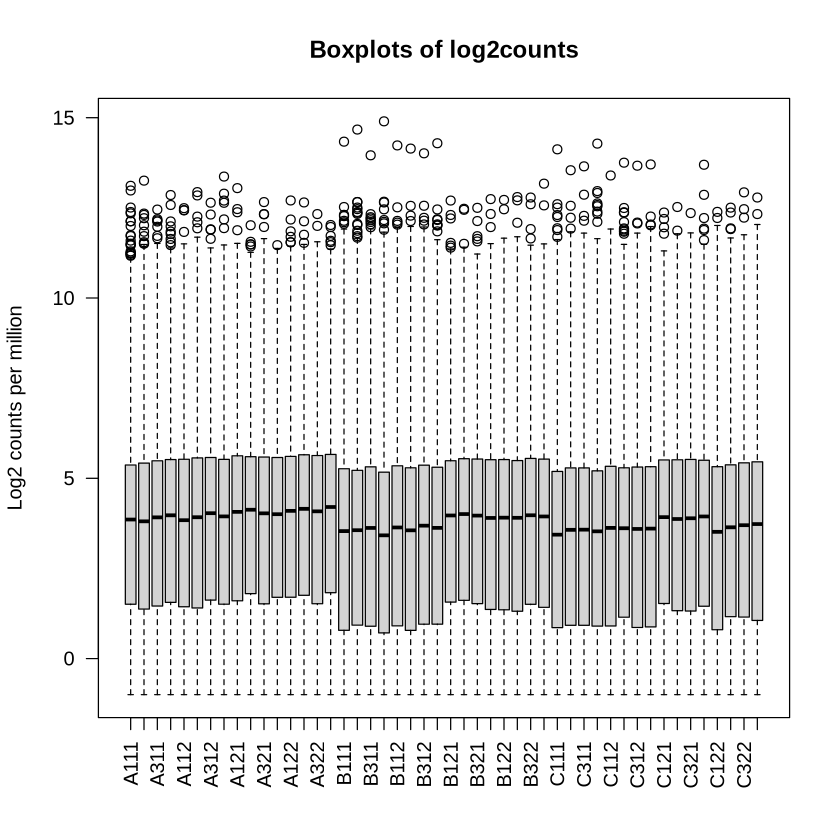

In [218]:
logcounts <- as.matrix(log2(myRPM.keep+0.5))
boxplot(logcounts, xlab="", ylab="Log2 counts per million",las=2)
title("Boxplots of log2counts")

In [219]:
# We estimate the variance for each row in the logcounts matrix
var_genes <- apply(logcounts, 1, var)
head(var_genes)
select_var <- names(sort(var_genes, decreasing=TRUE))[1:500]
head(select_var)

[1] 0.09307739 0.41360722 0.24248554 0.37665774 0.51638125 0.23119561

NULL

In [196]:
highly_variable_lRpm <- logcounts[select_var,]
dim(highly_variable_lRpm)

ERROR: Error in logcounts[select_var, ]: subscript out of bounds


In [42]:
install.packages('gplots')

also installing the dependencies ‘gtools’, ‘caTools’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [161]:
library(gplots)

In [162]:
heatmap.2(highly_variable_lRpm,trace="none", main="Top variable genes ",scale="row",cexCol=.8,cexRow=.8)


ERROR: Error in heatmap.2(highly_variable_lRpm, trace = "none", main = "Top variable genes ", : `x' must have at least 2 rows and 2 columns


In [46]:
library(NMF)


Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attaching package: ‘NMF’


The following object is masked from ‘package:S4Vectors’:

    nrun




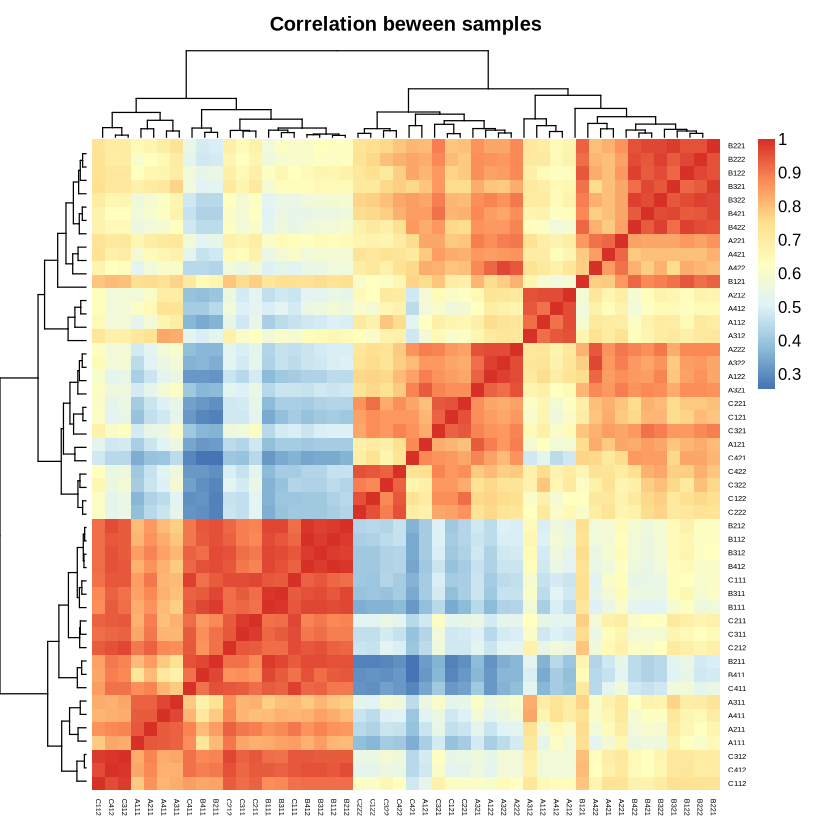

In [49]:
corr <- cor(myRPM.keep)
aheatmap(corr,main = "Correlation beween samples",labCol=sample_info$group,labRow=sample_info$group, width = 0.5, height = 0.5)



In [57]:
png(file=paste(output_directory,"correlations_heatmap.png",sep="/"))
aheatmap(corr,main = "Correlation beween samples",labCol=sample_info$group,labRow=sample_info$group, width =2, height = 2)
dev.off()

png 
  2

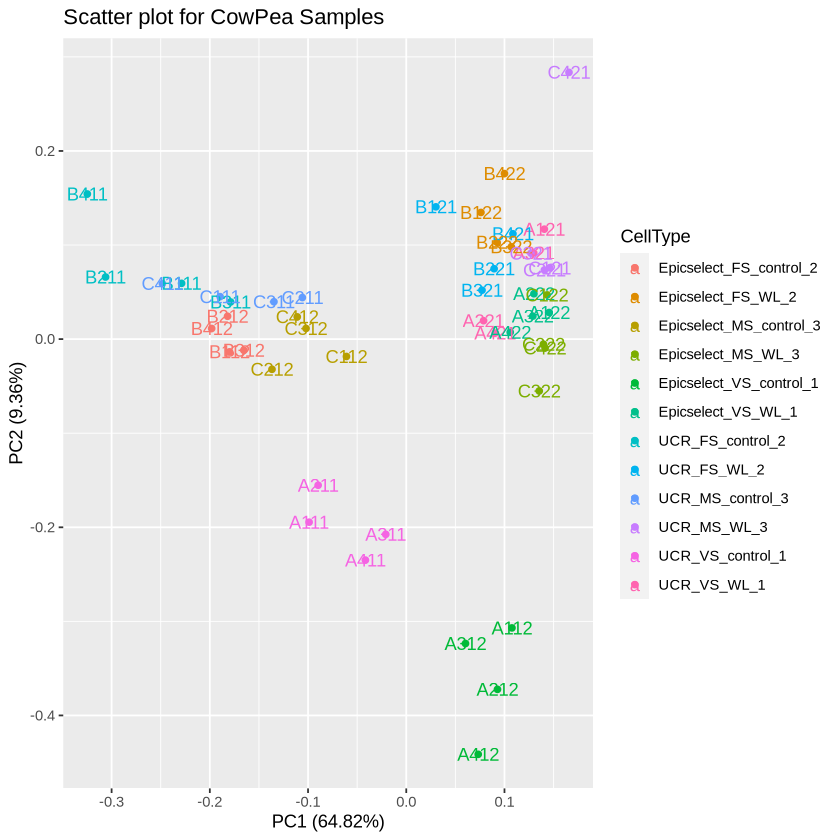

In [41]:
RPMforPCA <- t(myRPM.keep)
RPMforPCA <- as.data.frame(RPMforPCA)
RPMforPCA$CellType <- group
pc <- prcomp(RPMforPCA[,1:ncol(RPMforPCA)-1])
autoplot(pc, data = RPMforPCA, label = TRUE,   colour = 'CellType')+ggplot2::ggtitle("Scatter plot for CowPea Samples")


In [44]:
output_directory = "/scratch/sah2p/datasets/2023_11_05_MohitCowPea/output"
png(file=paste(output_directory,"pca_results.png",sep="/"))
autoplot(pc, data = RPMforPCA, label = TRUE,  colour = 'CellType')+ggplot2::ggtitle("Scatter plot for CowPea Samples")
dev.off()

png 
  2

#### DESEQ2

In [2]:
# install.packages('pheatmap')
install.packages('DEGreport')

Warning message:
“package ‘DEGreport’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


In [5]:
library(tidyverse)
library(RColorBrewer)
library(DESeq2)
library(pheatmap)
library(DEGreport)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’

In [4]:
data <- read.table("/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_quant_isr_counts.tsv", header=T, row.names=1) 

meta <- read.table("/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_rnaseq_sample_list.tsv", header=T, row.names=1)

In [5]:
meta$sample_type <- paste(meta$genotype,meta$tissue, meta$treatment, meta$time_point, sep='_')


In [10]:
comparelist <- read.table("/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_comp.tsv", header=TRUE,)

In [15]:
desired_sample_types <- c('UCR_VS_control_1', 'UCR_VS_WL_1')

filtered_samples <- subset(meta, sample_type %in% desired_sample_types)
filtered_samples

,genotype,tissue,treatment,time_point,replicate,sample_type
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
A111,UCR,VS,control,1,r1,UCR_VS_control_1
A211,UCR,VS,control,1,r2,UCR_VS_control_1
A311,UCR,VS,control,1,r3,UCR_VS_control_1
A411,UCR,VS,control,1,r4,UCR_VS_control_1
A121,UCR,VS,WL,1,r1,UCR_VS_WL_1
A221,UCR,VS,WL,1,r2,UCR_VS_WL_1
A321,UCR,VS,WL,1,r3,UCR_VS_WL_1
A421,UCR,VS,WL,1,r4,UCR_VS_WL_1


In [11]:
comparelist

Comparison1,X.,Comparison2
<chr>,<chr>,<chr>
UCR_VS_control_1,-,UCR_VS_WL_1
Epicselect_VS_control_1,-,Epicselect_VS_WL_1
UCR_FS_control_2,-,UCR_FS_WL_2
Epicselect_FS_control_2,-,Epicselect_FS_WL_2
UCR_MS_control_3,-,UCR_MS_WL_3
Epicselect_MS_control_3,-,Epicselect_MS_WL_3
UCR_VS_control_1,-,Epicselect_VS_control_1
UCR_VS_WL_1,-,Epicselect_VS_WL_1
UCR_FS_control_2,-,Epicselect_FS_control_2


In [50]:
dds <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~sample_type)


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [51]:
## Run analysis
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [ ]:
## Check the size factors
sizeFactors(dds)

: 

In [54]:
## Total number of raw counts per sample
colSums(counts(dds))


A111      A211      A311      A411      A112      A212      A312      A412 
 90056923  95609058  89444183  81752164  63822480  87136881  90341043  77156928 
     A121      A221      A321      A421      A122      A222      A322      A422 
 95347080 107862501  57068730  64055383  65378078  76150686  63672025  66876369 
     B111      B211      B311      B411      B112      B212      B312      B412 
 80180045  78424364  70426851  71132448  77011407  72102068  77911807  79918099 
     B121      B221      B321      B421      B122      B222      B322      B422 
 82466954  81086655  75313221  74784521  65204866  55378428  72236408  72961759 
     C111      C211      C311      C411      C112      C212      C312      C412 
 77648159  66580492  76573213  65060160  77229125  69926181  66685045  69416786 
     C121      C221      C321      C421      C122      C222      C322      C422 
 78868613  70608405  81197309  80491822  77314464  77608704  73151559  72635425

In [3]:
## Total number of normalized counts per sample
colSums(counts(dds, normalized=T))

NameError: name 'colSums' is not defined

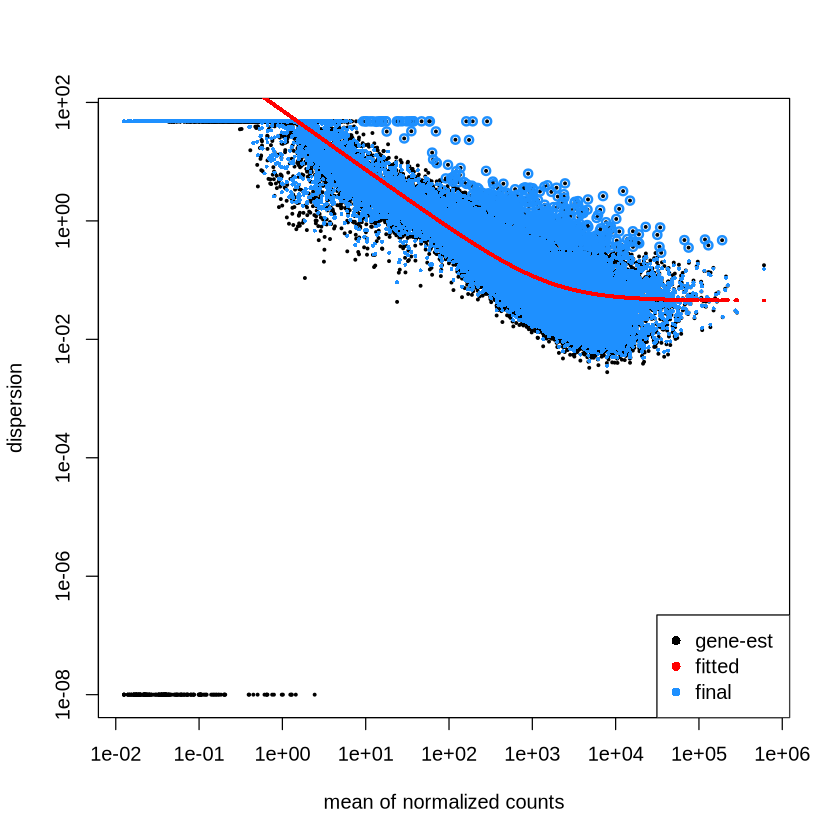

In [56]:
## Plot dispersion estimates
plotDispEsts(dds)

In [57]:
# UCR_VS_control_1 - UCR_VS_WL_1
contrast_UCRWL <- c("sample_type", "UCR_VS_WL_1","UCR_VS_control_1")
res_tbl_UCRWL_unshrunck <- results(dds, contrast_UCRWL, alpha=0.05)
rest_tbl_UCRWL <- lfcShrink(dds, contrast=contrast_UCRWL, res=res_tbl_UCRWL_unshrunck)


ERROR: Error in lfcShrink(dds, contrast = contrast_UCRWL, res = res_tbl_UCRWL_unshrunck): type='apeglm' shrinkage only for use with 'coef'


In [59]:
results(dds)

log2 fold change (MLE): sample type UCR VS WL 1 vs Epicselect FS control 2 
Wald test p-value: sample type UCR VS WL 1 vs Epicselect FS control 2 
DataFrame with 26339 rows and 6 columns
                      baseMean log2FoldChange     lfcSE       stat      pvalue
                     <numeric>      <numeric> <numeric>  <numeric>   <numeric>
VigunL059001.v1.2     0.309185       0.337076  7.212068  0.0467377 9.62722e-01
VigunL000101.v1.2     0.000000             NA        NA         NA          NA
VigunL000300.v1.2     3.746371      -1.823230  7.210325 -0.2528637 8.00374e-01
VigunL000202.v1.2     0.232625      -0.384173  7.212068 -0.0532681 9.57518e-01
VigunL001800.v1.2   969.506530       1.483780  0.320716  4.6264647 3.71960e-06
...                        ...            ...       ...        ...         ...
Vigun11g225800.v1.2   2201.500       0.089997  0.190224   0.473112 6.36134e-01
Vigun11g225900.v1.2   7364.495      -0.779289  0.172160  -4.526548 5.99551e-06
Vigun11g226000.v1.2    

In [ ]:
library(pheatmap)
library(RColorBrewer)
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("ComplexHeatmap")
# Load necessary libraries
library(readxl)
library(dplyr)
library(ComplexHeatmap)

: 

In [2]:
df <-read.csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/10_DistanceMatrix/All_genes_v2.csv", header=TRUE)
df[is.na(df)] <- 0


# Reading an Excel file
excel_path <- "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/gene_pathway/H3255_pathways.xlsx" # Update this path to your Excel file
df1 <- read_excel(excel_path, sheet = 'g2p')

# Extracting the "gene_" column into a list
gene_list <- df1$gene_ # Assuming 'gene_' is the name of the column


filtered_df <- df %>% filter(df$gene %in% gene_list) # Replace 'gene_column_in_df2' with the actual column name in df2 that corresponds to 'gene_'

# Viewing the filtered dataframe
colnames(filtered_df)
subset_df  <- filtered_df %>%
                select('gene','A549_E07_vs_A549_C362FC_greaterthan_.0.5.',
                'H1975_E07_vs_H1975_C362FC_greaterthan_.0.5.',
                'H3255_E07_vs_H3255_C362FC_greaterthan_.0.5.',
                'H820_E07_vs_H820_C362FC_greaterthan_.0.5.')
row.names(subset_df) <- subset_df$gene
colnames(subset_df) <- c('gene','A549',
                'H1975',
                'H3255',
                'H820')
subset_df$gene <- NULL

str(subset_df)

SyntaxError: invalid syntax (2327362273.py, line 2)

In [4]:
# selectedGenes <- names(sort(apply(subset_df, 1, var), 
                            # decreasing = T)[1:50])
# selectedGenes.dr

ERROR: Error in eval(expr, envir, enclos): object 'selectedGenes.dr' not found


Warning message:
“The input is a data frame, convert it to the matrix.”


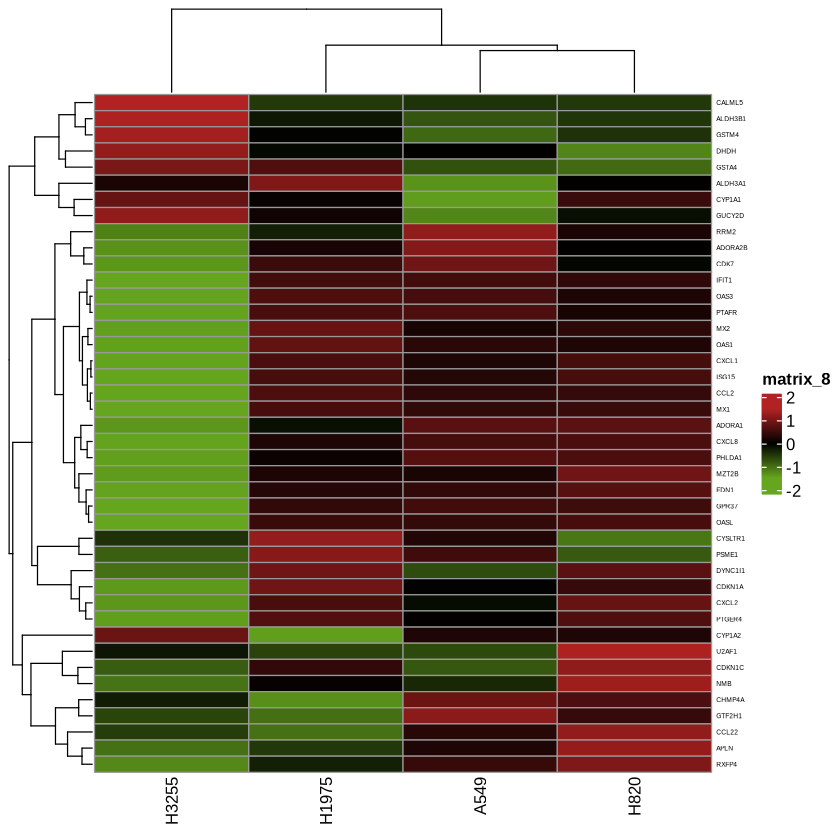

In [16]:
pheatmap(subset_df, 
             scale = 'row', 
            #  cutree_cols = 2, 
            #  cutree_rows = 2,
             fontsize_row = 4,
             show_rownames = TRUE,
             color=colorRampPalette(c("#66A61E", "black", "fireBrick"))(50),
        
            )




In [18]:
pheatmap(subset_df, 
             scale = 'row', 
            #  cutree_cols = 2, 
            #  cutree_rows = 2,
             fontsize_row = 4,
             show_rownames = TRUE,
             color=colorRampPalette(c("#66A61E", "black", "fireBrick"))(50),
        
            )

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
library(ComplexHeatmap)
library(circlize)

col_fun = colorRamp2(c(-2, 0, 2), c("green", "black", "firebrick"))
col_fun(seq(-3, 3))


Heatmap(subset_df, name = "log2FC", 
column_names_gp = grid::gpar(fontsize = 8),
  row_names_gp = grid::gpar(fontsize = 8),
    col = col_fun)



SyntaxError: invalid syntax (3757100282.py, line 9)

In [ ]:
df_fpkms <- read.csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/06_fpkm_csv/fpkm_all_samples_avg.csv", row.names = 1)


In [ ]:
library(ComplexHeatmap)
library(circlize)
cor_mat <- cor(df_fpkms)
# col_fun = colorRamp2(c(-1, 0, 1), c("green", "black", "firebrick"))
# col_fun(seq(-1 ,1))
output_path = "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/plots/heatmap/"
png(paste0(output_path,"correlation_heatmap.png")) # Opens a PNG device
Heatmap(cor_mat, name = "Pearson", 
    cell_fun = function(j, i, x, y, width, height, fill) {
        grid.text(sprintf("%.1f", cor_mat[i, j]), x, y, gp = gpar(fontsize = 10))
})
dev.off()  # Closes the device


png 
  2

In [2]:
library(ComplexHeatmap)
library(circlize)
cor_mat <- cor(df_fpkms)
# col_fun = colorRamp2(c(-1, 0, 1), c("green", "black", "firebrick"))
# col_fun(seq(-1 ,1))
h<-Heatmap(cor_mat, name = "Pearson", 
    cell_fun = function(j, i, x, y, width, height, fill) {
        grid.text(sprintf("%.1f", cor_mat[i, j]), x, y, gp = gpar(fontsize = 10))
})

ggsave("ggsavetest_2.png",dpi = 300, plot = h)


SyntaxError: invalid syntax (3983286628.py, line 7)

In [27]:
library(ggplot2)


In [6]:
colnames(df)

[1] "gene"                                       
 [2] "A549_E07_vs_A549_C362FC_greaterthan_.0.5."  
 [3] "H1975_E07_vs_H1975_Veh2FC_greaterthan_.0.5."
 [4] "H3255_C36_vs_H3255_Veh2FC_greaterthan_.0.5."
 [5] "H1975_E07_vs_H1975_C362FC_greaterthan_.0.5."
 [6] "H3255_E07_vs_H3255_Veh2FC_greaterthan_.0.5."
 [7] "H1975_C36_vs_H1975_Veh2FC_greaterthan_.0.5."
 [8] "H3255_E07_vs_H3255_C362FC_greaterthan_.0.5."
 [9] "A549_C36_vs_A549_Veh2FC_greaterthan_.0.5."  
[10] "A549_E07_vs_A549_Veh2FC_greaterthan_.0.5."  
[11] "H820_C36_vs_H820_Veh2FC_greaterthan_.0.5."  
[12] "H820_E07_vs_H820_C362FC_greaterthan_.0.5."  
[13] "H820_E07_vs_H820_Veh2FC_greaterthan_.0.5."

In [1]:
install.packages('VennDiagram')
install.packages('openxlsx')
library(VennDiagram)
library(tidyverse)
library(openxlsx)

# set input and output file paths
context_path = 
input_directory <- "../output/8_cuffdiff/"
output_directory <- "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/9_DEG"

# Create a new Excel workbook
wb <- createWorkbook()
addWorksheet(wb, sheetName = "summary")

# read the CSV file (tab-delimited)
mydata <- read.delim("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/9_DEG/10_DEG_LIST01_(2)1_DEGenesList.csv")

# get unique partitions
unique.partition <- VennDiagram::get.venn.partitions(mydata)

# sort by count
unique.partition <- unique.partition[order(unique.partition$..count.., decreasing = TRUE),]

# create an empty list
list <- list()

# loop through each row and print
for (i in 1:nrow(unique.partition)) {
    # print(unique.partition[i,])
    # read coloumn ..set..
    set <- unique.partition[i,]$`..set..`
    genes <- unique.partition[i,]$..values..
    count <- unique.partition[i,]$..count..

    # parse set till "∖"
    set_parsed <- strsplit(set, "∖")[[1]][1]

    # create a row for the list
    row <- c(i, set_parsed, count)

    # add row to list
    list[[i]] <- row

    string_var <- paste("", i)
    addWorksheet(wb, sheetName = string_var)
    writeData(wb, sheet = string_var, x = genes)
}

# create header for dataframe
header <- c("id", "set", "count")

# create dataframe
df <- as.data.frame(do.call(rbind, list), stringsAsFactors = FALSE)

# assign header to dataframe
names(df) <- header
# print(df)

writeData(wb, sheet = "summary", x = df)
saveWorkbook(wb, file = paste0(output_directory,"upset_data.xlsx"), overwrite = TRUE)

SyntaxError: invalid syntax (1626884184.py, line 8)